#Librerías

Mejoras respecto a v1:
  1. Crítico WGAN-GP con InstanceNorm (eliminado BatchNorm)
  2. Logging separado de pérdidas G y Crítico con ejes Y independientes
  3. WGAN estándar con weight clipping (+ comparación adicional)
  4. Experimentos de hiperparámetros (run_experiment, agrego tabla comparativa de FID)

In [ ]:
import os, random, math, time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.models.feature_extraction import create_feature_extractor

from sklearn.model_selection import train_test_split

from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Config

In [ ]:
ls "/content/drive/My Drive/2026/Ciencias Cognitivas/Proyecto final/Messidor-2"

messidor_data.csv  preprocess/


In [ ]:
SEED = 42 #semilla para generadores (reproducibilidad)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #dispositivo de ejecución
print("Device:", device)

BASE_PATH = "/content/drive/My Drive/2026/Ciencias Cognitivas/Proyecto final/Messidor-2"
IMG_DIR   = os.path.join(BASE_PATH, "preprocess")
CSV_PATH  = os.path.join(BASE_PATH, "messidor_data.csv")

Device: cuda


##Entrenamiento

In [ ]:
IMG_SIZE = 128  #resolución final de las imágenes
NUM_WORKERS = 2 #num procesos paralelos para cargar datos.
PIN_MEMORY = True #optimiza la transferencia de datos CPU → GPU

BATCH_SIZE = 8 #16
EPOCHS_DCGAN = 50
EPOCHS_WGAN  = 50 #100 #WGAN-GP y WGAN-clip usan mismo epochs

##Salida

In [ ]:
# Outputs
OUT_BASE = "/content/drive/My Drive/2026/Ciencias Cognitivas/Proyecto final/gan_outputs_2"
OUT_DC   = os.path.join(OUT_BASE, "dcgan")
OUT_WG   = os.path.join(OUT_BASE, "wgan_gp")
OUT_WC   = os.path.join(OUT_BASE, "wgan_clip")
OUT_WC_v2 = os.path.join(OUT_BASE, "wgan_clip_v2")
OUT_EXP  = os.path.join(OUT_BASE, "experimentos")

for directorio in [OUT_DC, OUT_WG, OUT_WC, OUT_WC_v2, OUT_EXP]:
    os.makedirs(directorio, exist_ok=True)

NZ = 100   # ruido #entrada generador (vector latente)
NC = 3     # RGB, num canales de salida del generador

# EDA

In [ ]:
print("\n 1) Cargando CSV + chequeos")
df = pd.read_csv(CSV_PATH, encoding="latin-1")
print("Filas CSV. Cantidad de imágenes=", len(df))
print("Columnas:", df.columns.tolist())
df.head()


 1) Cargando CSV + chequeos
Filas CSV. Cantidad de imágenes= 1744
Columnas: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']


,id_code,diagnosis,adjudicated_dme,adjudicated_gradable
0,20051020_43808_0100_PP.png,0,0,1
1,20051020_43832_0100_PP.png,1,0,1
2,20051020_43882_0100_PP.png,1,0,1
3,20051020_43906_0100_PP.png,2,1,1
4,20051020_44261_0100_PP.png,0,0,1


In [ ]:
FILENAME_COL = "id_code"
LABEL_COL    = "diagnosis"

#normalizo
files = os.listdir(IMG_DIR)
available = {f.strip().lower() for f in files}
df[FILENAME_COL] = df[FILENAME_COL].astype(str).str.strip() #ids a texto
df["filename"] = df[FILENAME_COL].str.lower() #columna auxiliar para comparar

df = df[df["filename"].isin(available)].reset_index(drop=True) #descarto entradas en csv que no tengan imagen asociada en la carpeta
print("Imágenes (CSV ∩ carpeta):", len(df))
balance = df[LABEL_COL].value_counts().sort_index()
print("Distribución de clases:\n", balance)


Imágenes (CSV ∩ carpeta): 1744
Distribución de clases:
 diagnosis
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64


In [ ]:
df.head()

,id_code,diagnosis,adjudicated_dme,adjudicated_gradable,filename
0,20051020_43808_0100_PP.png,0,0,1,20051020_43808_0100_pp.png
1,20051020_43832_0100_PP.png,1,0,1,20051020_43832_0100_pp.png
2,20051020_43882_0100_PP.png,1,0,1,20051020_43882_0100_pp.png
3,20051020_43906_0100_PP.png,2,1,1,20051020_43906_0100_pp.png
4,20051020_44261_0100_PP.png,0,0,1,20051020_44261_0100_pp.png


In [ ]:
(balance / balance.sum() * 100).round(2)

,count
diagnosis,
0,58.31
1,15.48
2,19.90
3,4.30
4,2.01


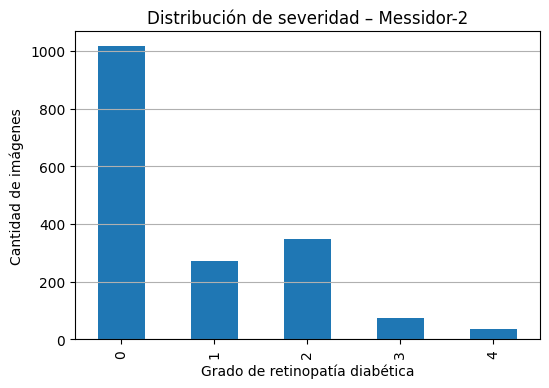

In [ ]:
plt.figure(figsize=(6,4))
balance.plot(kind="bar")
plt.xlabel("Grado de retinopatía diabética")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de severidad – Messidor-2")
plt.grid(axis="y")
plt.show()

##analisis resoluciones

In [ ]:
widths, heights = [], []
images = [
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for img_name in tqdm(images, desc="Resoluciones"):
    img = Image.open(os.path.join(IMG_DIR, img_name))
    w, h = img.size
    widths.append(w)
    heights.append(h)
print()
print(f"Resolución mínima: {min(widths)} × {min(heights)}")
print(f"Resolución máxima: {max(widths)} × {max(heights)}")
print(f"Resolución promedio: {int(sum(widths)/len(widths))} × {int(sum(heights)/len(heights))}")

Resoluciones: 100%|██████████| 1744/1744 [01:47<00:00, 16.25it/s] 


Resolución mínima: 512 × 512
Resolución máxima: 512 × 512
Resolución promedio: 512 × 512


##brillo y contraste

In [ ]:
brightness = []
variance = []

for img_name in tqdm(images, desc="Brillo/Contraste"):
    img = Image.open(os.path.join(IMG_DIR, img_name)).convert("L") #paso a escala de grises 0 a 255
    img_np = np.array(img)
    brightness.append(img_np.mean()) # brillo medio
    variance.append(img_np.var())    # contraste


Brillo/Contraste: 100%|██████████| 1744/1744 [02:15<00:00, 12.89it/s]


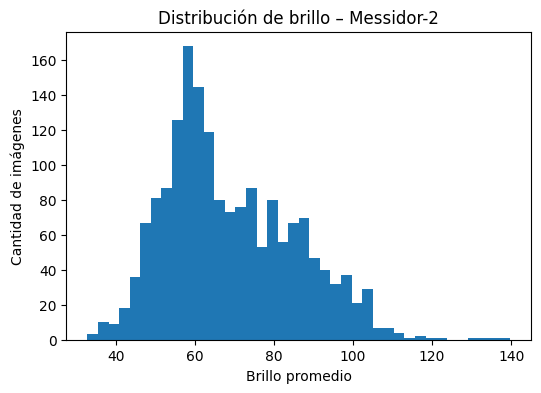

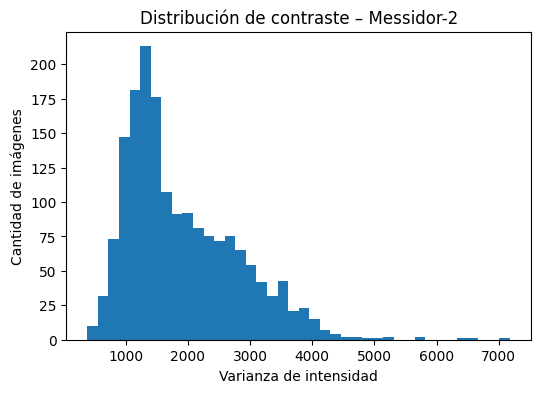

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(brightness, bins=40)
plt.xlabel("Brillo promedio")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de brillo – Messidor-2")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(variance, bins=40)
plt.xlabel("Varianza de intensidad")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de contraste – Messidor-2")
plt.show()

##tipo de imágenes

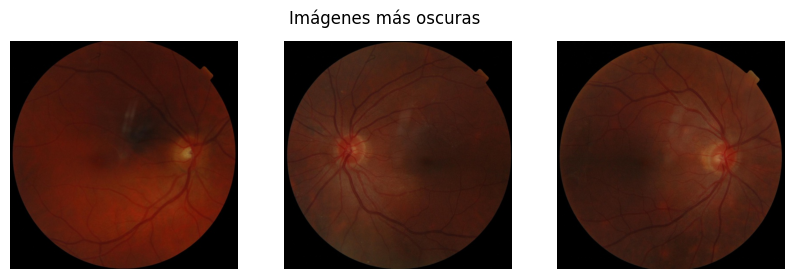

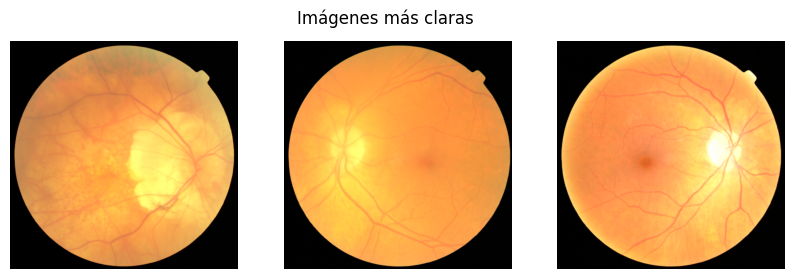

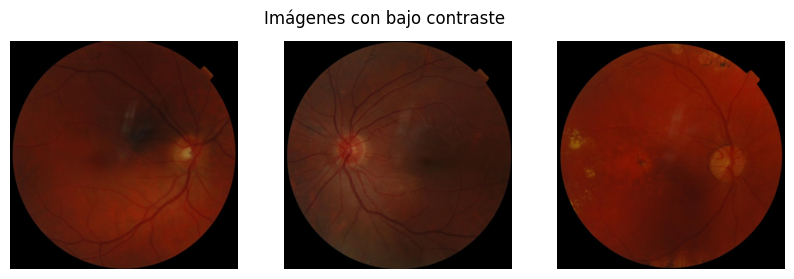

In [ ]:
import numpy as np

# brightness y variance vienen como listas pero np.argsort funciona mejor con arrays
brightness_arr = np.array(brightness)
variance_arr   = np.array(variance)
idx_dark = np.argsort(brightness_arr)[:3]
idx_bright = np.argsort(brightness_arr)[-3:]
idx_low_var = np.argsort(variance_arr)[:3]

def show_images(indices, title):
    plt.figure(figsize=(10,3))
    for i, idx in enumerate(indices):
        img = Image.open(os.path.join(IMG_DIR, images[idx]))
        plt.subplot(1, len(indices), i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(idx_dark, "Imágenes más oscuras")
show_images(idx_bright, "Imágenes más claras")
show_images(idx_low_var, "Imágenes con bajo contraste")


#Preprocesamiento

##train-test

In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df[LABEL_COL]
) #mantengo la proporción de clases en train y en validación
print("Train:", len(train_df), "Val:", len(val_df))

Train: 1395 Val: 349


##Transformaciones

In [ ]:
gan_tf = transforms.Compose([
    transforms.Resize(150),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3) #Convierte [0,1] → [-1,1]
])

##Construcción del Dataset y DataLoader

In [ ]:
class MessidorDataset(Dataset):
    def __init__(self, df, img_dir, filename_col, transform=None): #defino que necesita dataset
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.filename_col = filename_col
        self.transform = transform

    def __len__(self): #conteo de datos existentes
        return len(self.df)

    def __getitem__(self, idx): #obtengo muestras, se ejecuta cada vez que el dataloader pide un dato
        fname = self.df.loc[idx, self.filename_col]
        path = os.path.join(self.img_dir, fname)
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img #normalización a [-1,1] para que todas las imágenes tenga el mismo formato

train_ds = MessidorDataset(train_df, IMG_DIR, FILENAME_COL, transform=gan_tf)
val_ds   = MessidorDataset(val_df, IMG_DIR, FILENAME_COL, transform=gan_tf)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

###check DataLoader

Batch shape: torch.Size([8, 3, 128, 128]) | min/max: -1.0 1.0


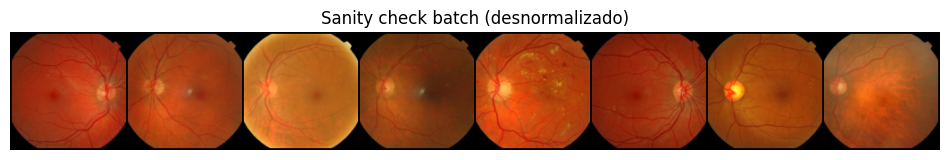

In [ ]:
batch = next(iter(train_loader))
print("Batch shape:", batch.shape, "| min/max:", batch.min().item(), batch.max().item())

def denorm(x): #para visualizar
    return (x*0.5 + 0.5).clamp(0,1) #[-1,1] → [0,1] para visualización

plt.figure(figsize=(12,4))
grid = make_grid(denorm(batch[:8]), nrow=8)
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Sanity check batch (desnormalizado)")
plt.show()

# Arquitectura

'''
Arquitecturas del generador y del discriminador/crítico.

- Generator: compartido entre los tres modelos (DCGAN, WGAN-GP, WGAN-clip).
  La comparación entre modelos se centra exclusivamente en la función de pérdida
  y el esquema de entrenamiento, manteniendo constante la arquitectura del generador.

- Discriminator_DCGAN: usa BatchNorm + Sigmoid. Exclusivo para DCGAN.

- Critic_WGAN: usa InstanceNorm (sin BatchNorm) y sin Sigmoid.
  Usado para WGAN-GP y WGAN-clip.
  BatchNorm está prohibido en el crítico de WGAN-GP porque introduce
  dependencias entre muestras del batch, corrompiendo el cálculo del
  gradient penalty
'''

##Generador

In [ ]:
NGF = 64 #número base de filtros del generador, va REDUCIENDO filtros a medida que aumenta la resolución espacial
NDF = 64 #número base de filtros del discriminador, va AUMENTANDO filtros a medida que reduce la resolución espacial
#generador
class Generador(nn.Module):
    '''
    Generador DCGAN estándar. Compartido entre DCGAN, WGAN-GP y WGAN-clip para que la comparación
    se centra exclusivamente en la función de pérdida y el esquema de entrenamiento
    '''
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),  # 4*4
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False), # 8*8
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), # 16*16
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),   # 32*32
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf//2, 4, 2, 1, bias=False),  # 64*64
            nn.BatchNorm2d(ngf//2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf//2, nc, 4, 2, 1, bias=False),   # 128*128
            nn.Tanh()
        )

    def forward(self, z):
      return self.net(z)

##Discriminador DCGAN con Sigmoid + BatchNorm
----BatchNorm solo para DCGAN

In [ ]:
#discriminador DCGAN con Sigmoid + BatchNorm
class D_DCGAN(nn.Module):
    '''
    Discriminador clásico para DCGAN.
    Usa BatchNorm y Sigmoid; NO apto para WGAN-GP.
    '''
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc,     ndf,    4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf,    ndf*2,  4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2,  ndf*4,  4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4,  ndf*8,  4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8,  ndf*16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*16), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*16, 1,      4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

## Crítico WGAN  (con InstanceNorm, sin BatchNorm, sin Sigmoid)

In [ ]:
class Critic_WGAN(nn.Module):
    '''
    Crítico para WGAN-GP y WGAN-clip.
    '''
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        self.net = nn.Sequential(
            # Bloque 1 – sin normalización en la primera capa (práctica estándar)
            nn.Conv2d(nc,     ndf,    4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 2
            nn.Conv2d(ndf,    ndf*2,  4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*2,  affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 3
            nn.Conv2d(ndf*2,  ndf*4,  4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*4,  affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 4
            nn.Conv2d(ndf*4,  ndf*8,  4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*8,  affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 5
            nn.Conv2d(ndf*8,  ndf*16, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*16, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Salida escalar, sin Sigmoid (valor real no acotado)
            nn.Conv2d(ndf*16, 1,      4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

# Funciones auxiliares

In [ ]:
def weights_init(m):
    '''
    Inicialización de pesos estándar DCGAN
    '''
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls or "InstanceNorm" in cls:
        if m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

# guardo muestras de imágenes por épocas
def save_grid_samples(netG, epoch, out_dir, fixed_noise, tag=""):
    netG.eval()
    with torch.no_grad():
        fake = denorm(netG(fixed_noise).detach().cpu())
        save_image(make_grid(fake, nrow=8),
                   os.path.join(out_dir, f"samples{tag}_epoch_{epoch:03d}.png"))
    netG.train()

## Visualización de pérdidas con ejes independientes

In [ ]:
def plot_losses_dual_axis(G_losses, C_losses, title, xlabel="Actualizaciones del generador"):
    '''
    Grafica G y Critic en ejes Y independientes para evitar que la diferencia de escala haga invisible una de las dos curvas.
    '''
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax2 = ax1.twinx()

    ax1.plot(G_losses, color="steelblue", linewidth=1.2, label="Generador")
    ax2.plot(C_losses, color="tomato",    linewidth=1.0, alpha=0.8, label="Crítico/Discriminador")

    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Pérdida – Generador", color="steelblue")
    ax2.set_ylabel("Pérdida – Crítico",   color="tomato")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#Lipschitz condición

In [ ]:
def gradient_penalty(critic, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=device)
    interp = eps * real + (1-eps) * fake
    interp.requires_grad_(True)

    pred = critic(interp)
    grads = torch.autograd.grad(
        outputs=pred,
        inputs=interp,
        grad_outputs=torch.ones_like(pred),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grads = grads.view(b, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp

#Entrenamiento

##DCGAN

In [ ]:
def train_dcgan(num_epochs, lr=2e-4, beta1=0.5, label_smoothing=True):
    '''
    Entreno una DCGAN estándar con BCE loss (Binary Cross Entropy, función de pérdida que usa DCGAN.
    Binaria porque el discriminador tiene que tomar una decicisón entre 2 clases).
    Clases:
      real  -> 1
      falsa -> 0

    fórmula: BCE = -[y · log(ŷ) + (1-y) · log(1-ŷ)]
    y es la etiqueta real (0 o 1)
    ŷ es la predicción del discriminador (valor entre 0 y 1 gracias al Sigmoid)

    Actúa como modelo base de comparación.
    '''
    netG = Generador().to(device)
    netD = D_DCGAN().to(device)
    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.BCELoss()
    optG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
    optD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))

    fixed_noise = torch.randn(64, NZ, 1, 1, device=device)
    G_losses, D_losses = [], []

    for epoch in range(1, num_epochs + 1):
        g_epoch, d_epoch = [], []
        for real in train_loader:
            real = real.to(device)
            b    = real.size(0)

            real_y = torch.empty(b, device=device).uniform_(0.8, 1.0) if label_smoothing \
                     else torch.ones(b, device=device)
            fake_y = torch.empty(b, device=device).uniform_(0.0, 0.2) if label_smoothing \
                     else torch.zeros(b, device=device)

            # Discriminador
            netD.zero_grad()
            lossD = criterion(netD(real), real_y)
            z     = torch.randn(b, NZ, 1, 1, device=device)
            fake  = netG(z)
            lossD = lossD + criterion(netD(fake.detach()), fake_y)
            lossD.backward(); optD.step()

            # Generador
            netG.zero_grad()
            lossG = criterion(netD(fake), real_y)
            lossG.backward(); optG.step()

            g_epoch.append(lossG.item())
            d_epoch.append(lossD.item())

        G_losses.append(np.mean(g_epoch))
        D_losses.append(np.mean(d_epoch))

        if epoch % 5 == 0 or epoch == 1:
            print(f"[DCGAN] Epoch {epoch:03d}/{num_epochs} | "
                  f"LossD: {D_losses[-1]:.4f} | LossG: {G_losses[-1]:.4f}")
            save_grid_samples(netG, epoch, OUT_DC, fixed_noise)

    plot_losses_dual_axis(G_losses, D_losses,
                          "DCGAN – Pérdidas por época (ejes independientes)",
                          xlabel="Época")
    return netG, netD, G_losses, D_losses

##WGAN-GP

In [ ]:
def train_wgan_gp(num_epochs, lr=1e-4, beta1=0.0, beta2=0.9, n_critic=5, lambda_gp=10, out_dir=OUT_WG, tag=""):
    '''
    Entrena WGAN-GP con:
      - Critic_WGAN (InstanceNorm, sin Sigmoid)
      - Adam(beta1=0, beta2=0.9)
      - Logging por época (promedio de batches) para curvas legibles
      - Plot con ejes Y independientes para G y Critic
    '''
    netG   = Generador().to(device)
    critic = Critic_WGAN().to(device)
    netG.apply(weights_init)
    critic.apply(weights_init)

    #Adam con beta1=0 recomendación del paper WGAN-GP
    optG = optim.Adam(netG.parameters(),   lr=lr, betas=(beta1, beta2))
    optC = optim.Adam(critic.parameters(), lr=lr, betas=(beta1, beta2))

    fixed_noise = torch.randn(64, NZ, 1, 1, device=device)
    G_losses, C_losses = [], []   # promedio por época
    step = 0

    for epoch in range(1, num_epochs + 1):
        g_epoch, c_epoch, lossG = [], [], None

        for real in train_loader:
            real = real.to(device)
            b    = real.size(0)
            step += 1

            #Actualizar crítico
            z    = torch.randn(b, NZ, 1, 1, device=device)
            fake = netG(z).detach()

            gp    = gradient_penalty(critic, real, fake)
            lossC = -(critic(real).mean() - critic(fake).mean()) + lambda_gp * gp

            critic.zero_grad()
            lossC.backward()
            optC.step()
            c_epoch.append(lossC.item())

            #Actualizar generador cada n_critic pasos
            if step % n_critic == 0:
                z     = torch.randn(b, NZ, 1, 1, device=device)
                lossG = -critic(netG(z)).mean()
                netG.zero_grad()
                lossG.backward()
                optG.step()
                g_epoch.append(lossG.item())

        #Promedio por época, evita la variabilidad batch-a-batch que genera picos
        C_losses.append(np.mean(c_epoch))
        G_losses.append(np.mean(g_epoch) if g_epoch else float("nan"))

        if epoch % 5 == 0 or epoch == 1:
            g_val = G_losses[-1] if not np.isnan(G_losses[-1]) else float("nan")
            print(f"[WGAN-GP{tag}] Epoch {epoch:03d}/{num_epochs} | "
                  f"LossC: {C_losses[-1]:.4f} | LossG: {g_val:.4f}")
            save_grid_samples(netG, epoch, out_dir, fixed_noise, tag=tag)

    plot_losses_dual_axis(G_losses, C_losses,
                          f"WGAN-GP{tag} – Pérdidas por época (ejes independientes)")
    return netG, critic, G_losses, C_losses

##WGAN con weight clipping

In [ ]:
def train_wgan_clip(num_epochs, lr=5e-5, clip_value=0.01, n_critic=5):
    '''
    WGAN estándar con weight clipping. Diferencias clave respecto a WGAN-GP:
      - Condición Lipschitz por pesos en lugar de gradient penalty.
      - Optimizador RMSprop (recomendación de paper, distinto de Adam en GP).
      - Sin InstanceNorm en el crítico (el clipping ya impone Lipschitz).
      - Sirve como punto de comparación intermedio entre DCGAN y WGAN-GP.

    Limitación conocida: el clipping puede llevar a gradientes que desaparecen
    o explotan dependiendo del valor de clip_value, y restringe la capacidad
    expresiva del crítico.
    '''
    netG   = Generador().to(device)
    critic = Critic_WGAN().to(device)   #mismo crítico sin Sigmoid
    netG.apply(weights_init)
    critic.apply(weights_init)

    #RMSprop: optimizador recomendado
    optG = optim.RMSprop(netG.parameters(),   lr=lr)
    optC = optim.RMSprop(critic.parameters(), lr=lr)

    fixed_noise = torch.randn(64, NZ, 1, 1, device=device)
    G_losses, C_losses = [], []
    step = 0

    for epoch in range(1, num_epochs + 1):
        g_epoch, c_epoch, lossG = [], [], None

        for real in train_loader:
            real = real.to(device)
            b    = real.size(0)
            step += 1

            #Actualizar crítico
            z    = torch.randn(b, NZ, 1, 1, device=device)
            fake = netG(z).detach()

            lossC = -(critic(real).mean() - critic(fake).mean())
            critic.zero_grad()
            lossC.backward()
            optC.step()

            #Weight clipping– impone condición de Lipschitz
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

            c_epoch.append(lossC.item())

            # Actualizar generador cada n_critic pasos
            if step % n_critic == 0:
                z     = torch.randn(b, NZ, 1, 1, device=device)
                lossG = -critic(netG(z)).mean()
                netG.zero_grad()
                lossG.backward()
                optG.step()
                g_epoch.append(lossG.item())

        C_losses.append(np.mean(c_epoch))
        G_losses.append(np.mean(g_epoch) if g_epoch else float("nan"))

        if epoch % 5 == 0 or epoch == 1:
            g_val = G_losses[-1] if not np.isnan(G_losses[-1]) else float("nan")
            print(f"[WGAN-clip] Epoch {epoch:03d}/{num_epochs} | "
                  f"LossC: {C_losses[-1]:.4f} | LossG: {g_val:.4f}")
            save_grid_samples(netG, epoch, OUT_WC, fixed_noise)

    plot_losses_dual_axis(G_losses, C_losses,
                          "WGAN-clip – Pérdidas por época (ejes independientes)")
    return netG, critic, G_losses, C_losses

# Experimentos de hiperparámetros

##  Configuraciones (HP_CONFIGS)

In [ ]:
'''
Se prueban 4 configuraciones de WGAN-GP variando lambda_gp y n_critic.
Todas usan lr=1e-4, Adam(beta1=0, beta2=0.9) y Critic_WGAN (InstanceNorm).
Los resultados se comparan mediante FID y se presentan en tabla.

Nota: Config A (BatchNorm en crítico) fue descartada por generar inestabilidad
en el gradient penalty (FID=138.14) y se documenta en Sección III-E del informe.
Config B = valores de referencia lambda=10, n_critic=5
Config C = crítico menos frecuente n_critic=3
Config D = penalización más suave lambda=5
Config E = penalización suave + lr conservador n_critic=3
'''

HP_CONFIGS = [
    {"name": "B_lam10_nc5", "lambda_gp": 10, "n_critic": 5, "lr": 1e-4},
    {"name": "C_lam10_nc3", "lambda_gp": 10, "n_critic": 3, "lr": 1e-4},
    {"name": "D_lam5_nc5",  "lambda_gp":  5, "n_critic": 5, "lr": 1e-4},
    {"name": "E_lam5_nc3",  "lambda_gp":  5, "n_critic": 3, "lr": 5e-5},
]


##  Ejecución (run_experiment)

In [ ]:
def run_experiment(cfg, num_epochs=EPOCHS_WGAN):
    '''
    Se entrena WGAN-GP con la configuración cfg y devuelve FID + métricas de diversidad.
    Guarda imágenes en OUT_EXP/<name>/.
    '''
    out_dir = os.path.join(OUT_EXP, cfg["name"])
    os.makedirs(out_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"  Experimento: {cfg['name']}")
    print(f"  lambda_gp={cfg['lambda_gp']} | n_critic={cfg['n_critic']} | lr={cfg['lr']}")
    print(f"{'='*60}")

    netG, _, G_losses, C_losses = train_wgan_gp(
        num_epochs  = num_epochs,
        lr          = cfg["lr"],
        n_critic    = cfg["n_critic"],
        lambda_gp   = cfg["lambda_gp"],
        out_dir     = out_dir,
        tag         = f"_{cfg['name']}"
    )

    torch.save(netG.state_dict(), os.path.join(out_dir, f"wgangp_G_{cfg['name']}_final.pt")) #guardo modelos luego del entrenamiento
    print(f"WGAN-GP {cfg['name']} guardado")

    print(f"Calculando FID para {cfg['name']}...")
    fid = compute_fid(netG)

    print(f"Calculando diversidad para {cfg['name']}...")
    div = analyze_generator_behavior(netG)

    return {
        "config"              : cfg["name"],
        "lambda_gp"           : cfg["lambda_gp"],
        "n_critic"            : cfg["n_critic"],
        "lr"                  : cfg["lr"],
        "FID"                 : fid,
        "pixel_variance"      : div["pixel_variance"],
        "mean_pairwise_distance"  : div["mean_pairwise_distance"],
        "model"               : netG,
    }

def plot_comparison_all(dcgan_G, wganclip_G, exp_results):
    '''
    Grid cualitativo: DCGAN | WGAN-clip | WGAN-GP (mejor config) con el mismo z.
    '''
    best = min(exp_results, key=lambda r: r["FID"])
    wgangp_G = best["model"]

    models = {
        "DCGAN"          : dcgan_G,
        "WGAN-clip"      : wganclip_G,
        f"WGAN-GP ({best['config']})" : wgangp_G,
    }
    z = torch.randn(16, NZ, 1, 1, device=device)

    fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5))
    for ax, (title, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            fake = denorm(model(z).cpu())
        grid = make_grid(fake, nrow=4, padding=2)
        ax.imshow(grid.permute(1, 2, 0))
        ax.set_title(title, fontsize=11)
        ax.axis("off")

    plt.suptitle("Comparación cualitativa – mismo vector latente", fontsize=13)
    plt.tight_layout()
    plt.show()


def print_results_table(dcgan_fid, wganclip_fid, exp_results,
                        dcgan_div, wganclip_div):
    #Imprime tabla comparativa en consola
    print("\n" + "="*80)
    print(f"{'Modelo':<28} {'FID':>8} {'Var. pix':>12} {'Dist. media':>13}")
    print("-"*80)
    print(f"{'DCGAN (baseline)':<28} {dcgan_fid:>8.2f} "
          f"{dcgan_div['pixel_variance']:>12.6f} "
          f"{dcgan_div['mean_pairwise_distance']:>13.4f}")
    print(f"{'WGAN-clip':<28} {wganclip_fid:>8.2f} "
          f"{wganclip_div['pixel_variance']:>12.6f} "
          f"{wganclip_div['mean_pairwise_distance']:>13.4f}")
    for r in exp_results:
        name = f"WGAN-GP ({r['config']})"
        print(f"{name:<28} {r['FID']:>8.2f} "
              f"{r['pixel_variance']:>12.6f} "
              f"{r['mean_pairwise_distance']:>13.4f}")
    print("="*80)

# Evaluación

## FID - evaluación cuantitativa

In [ ]:
def compute_fid(netG, n_samples=512, batch_size=32):
    '''
    Calcula Fréchet Inception Distance usando activaciones del avg-pool de InceptionV3.
    Un menor FID indica mayor similitud estadística entre distribuciones real y generada.
    '''
    from numpy import cov, trace, iscomplexobj
    from scipy.linalg import sqrtm

    #Imágenes reales
    real_imgs = []
    for b in train_loader:
        real_imgs.append(denorm(b.cpu()))
        if sum(x.size(0) for x in real_imgs) >= n_samples:
            break
    real_imgs = torch.cat(real_imgs)[:n_samples]

    #Imágenes generadas
    netG.eval()
    fake_imgs = []
    with torch.no_grad():
        for _ in range(math.ceil(n_samples / 64)):
            z    = torch.randn(64, NZ, 1, 1, device=device)
            fake = denorm(netG(z).detach().cpu())
            fake_imgs.append(fake)
    netG.train()
    fake_imgs = torch.cat(fake_imgs)[:n_samples]

    #InceptionV3
    weights = Inception_V3_Weights.DEFAULT
    inc  = inception_v3(weights=weights, aux_logits=True).to(device)
    feat = create_feature_extractor(inc, return_nodes={"avgpool": "feat"}).to(device)
    feat.eval()

    @torch.no_grad()
    def activations(imgs):
        arr = np.empty((imgs.size(0), 2048), dtype=np.float32)
        for i in range(0, imgs.size(0), batch_size):
            x   = F.interpolate(imgs[i:i+batch_size].to(device),
                                 size=(299, 299), mode="bilinear", align_corners=False)
            out = feat(x)["feat"].squeeze(-1).squeeze(-1)
            arr[i:i+out.size(0)] = out.cpu().numpy()
        return arr

    a1 = activations(real_imgs)
    a2 = activations(fake_imgs)

    mu1, s1  = a1.mean(0), cov(a1, rowvar=False)
    mu2, s2  = a2.mean(0), cov(a2, rowvar=False)
    ssd      = np.sum((mu1 - mu2) ** 2)
    covmean  = sqrtm(s1.dot(s2))
    if iscomplexobj(covmean):
        covmean = covmean.real
    fid = float(ssd + trace(s1 + s2 - 2.0 * covmean))
    print(f"  FID = {fid:.2f}")
    return fid

##Análisis paramétrico (diversidad del generador)

In [ ]:
def analyze_generator_behavior(netG, n_samples=256, batch_size=64):
    netG.eval()
    imgs = []
    with torch.no_grad():
        for _ in range(n_samples // batch_size):
            z    = torch.randn(batch_size, NZ, 1, 1, device=device) #genero img falsas
            fake = denorm(netG(z).detach().cpu())
            imgs.append(fake)
    imgs = torch.cat(imgs)[:n_samples]
    netG.train()

    pixel_var  = imgs.var(dim=0).mean().item() #métrica 1: varianza global (proxy de diversidad en pixeles)
    imgs_flat  = imgs.view(n_samples, -1)      #métrica 2: distancia promedio entre imágenes
    mean_dist  = torch.cdist(imgs_flat, imgs_flat, p=2).mean().item()

    print(f"Varianza promedio de píxeles: {pixel_var:.6f}")
    print(f"Distancia promedio inter-img: {mean_dist:.4f}")
    return {
        "pixel_variance": pixel_var,
        "mean_pairwise_distance": mean_dist
        }

#MODELOS train

##DCGAN baseline para comparar con WGAN-GP y WGAN-clip.


  Entrenando DCGAN (baseline)
[DCGAN] Epoch 001/50 | LossD: 12.4611 | LossG: 36.2141
[DCGAN] Epoch 005/50 | LossD: 0.9382 | LossG: 2.5973
[DCGAN] Epoch 010/50 | LossD: 1.0187 | LossG: 2.3960
[DCGAN] Epoch 015/50 | LossD: 1.0556 | LossG: 2.2301
[DCGAN] Epoch 020/50 | LossD: 1.1468 | LossG: 2.2106
[DCGAN] Epoch 025/50 | LossD: 1.0608 | LossG: 2.5200
[DCGAN] Epoch 030/50 | LossD: 0.9706 | LossG: 2.5886
[DCGAN] Epoch 035/50 | LossD: 0.9501 | LossG: 2.6275
[DCGAN] Epoch 040/50 | LossD: 0.8797 | LossG: 2.7075
[DCGAN] Epoch 045/50 | LossD: 0.8817 | LossG: 2.7213
[DCGAN] Epoch 050/50 | LossD: 0.8594 | LossG: 2.6500


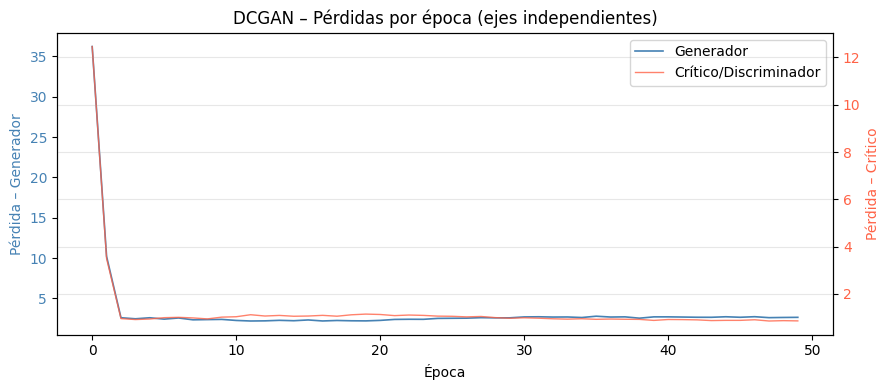


FID – DCGAN:


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 47.61

Diversidad – DCGAN:
Varianza promedio de píxeles: 0.012743
Distancia promedio inter-img: 31.0789


In [ ]:
print("\n" + "="*60)
print("  Entrenando DCGAN (baseline)")
print("="*60)
dcgan_G, dcgan_D, dc_Gloss, dc_Dloss = train_dcgan(EPOCHS_DCGAN)

print("\nFID – DCGAN:")
fid_dcgan  = compute_fid(dcgan_G)
print("\nDiversidad – DCGAN:")
div_dcgan  = analyze_generator_behavior(dcgan_G)

###Guardo modelo después de entrenamiento

In [ ]:
torch.save(dcgan_G.state_dict(), os.path.join(OUT_DC, "dcgan_G_final.pt"))
torch.save(dcgan_D.state_dict(), os.path.join(OUT_DC, "dcgan_D_final.pt"))
print("DCGAN guardado")

DCGAN guardado


##WGAN con weight clipping


  Entrenando WGAN-clip
[WGAN-clip] Epoch 001/50 | LossC: -1.3456 | LossG: 0.5217
[WGAN-clip] Epoch 005/50 | LossC: -2.8845 | LossG: 1.3234
[WGAN-clip] Epoch 010/50 | LossC: -2.9056 | LossG: 1.3202
[WGAN-clip] Epoch 015/50 | LossC: -2.9118 | LossG: 1.3206
[WGAN-clip] Epoch 020/50 | LossC: -2.9142 | LossG: 1.3215
[WGAN-clip] Epoch 025/50 | LossC: -2.9156 | LossG: 1.3223
[WGAN-clip] Epoch 030/50 | LossC: -2.9165 | LossG: 1.3226
[WGAN-clip] Epoch 035/50 | LossC: -2.9172 | LossG: 1.3231
[WGAN-clip] Epoch 040/50 | LossC: -2.9174 | LossG: 1.3231
[WGAN-clip] Epoch 045/50 | LossC: -2.9155 | LossG: 1.3225
[WGAN-clip] Epoch 050/50 | LossC: -2.9164 | LossG: 1.3231


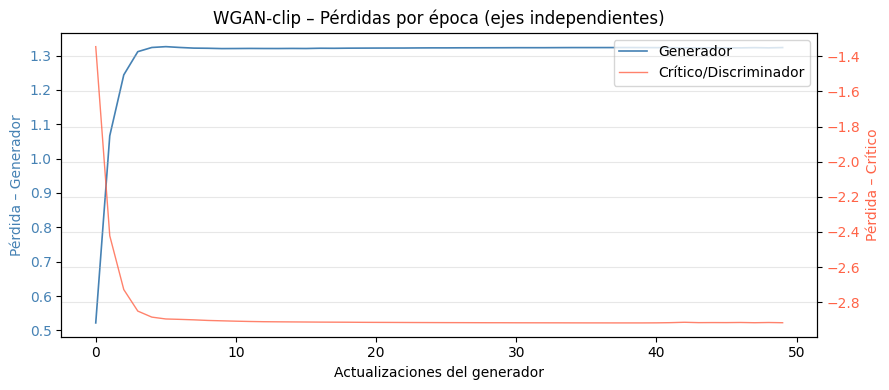


FID – WGAN-clip:


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 354.54

Diversidad – WGAN-clip:
Varianza promedio de píxeles: 0.009592
Distancia promedio inter-img: 30.1232


In [ ]:
print("\n" + "="*60)
print("  Entrenando WGAN-clip")
print("="*60)
wganclip_G, wganclip_C, wc_Gloss, wc_Closs = train_wgan_clip(EPOCHS_WGAN)

print("\nFID – WGAN-clip:")
fid_wganclip = compute_fid(wganclip_G)
print("\nDiversidad – WGAN-clip:")
div_wganclip = analyze_generator_behavior(wganclip_G)

###Guardo modelo

In [ ]:
torch.save(wganclip_G.state_dict(), os.path.join(OUT_WC, "wganclip_G_final.pt"))
print("WGAN-clip guardado")

WGAN-clip guardado


##WGAN con weight clipping con lr=1e-4 y clip_value=0.05


  Entrenando WGAN-clip con lr=1e-4 y clip_value=0.05
[WGAN-clip] Epoch 001/50 | LossC: -28.8754 | LossG: 12.7665
[WGAN-clip] Epoch 005/50 | LossC: -76.0371 | LossG: 37.7531
[WGAN-clip] Epoch 010/50 | LossC: -76.2269 | LossG: 37.1363
[WGAN-clip] Epoch 015/50 | LossC: -76.2924 | LossG: 37.0507
[WGAN-clip] Epoch 020/50 | LossC: -76.3078 | LossG: 37.0378
[WGAN-clip] Epoch 025/50 | LossC: -76.3226 | LossG: 37.0422
[WGAN-clip] Epoch 030/50 | LossC: -76.3337 | LossG: 37.0453
[WGAN-clip] Epoch 035/50 | LossC: -76.3427 | LossG: 37.0495
[WGAN-clip] Epoch 040/50 | LossC: -76.3479 | LossG: 37.0513
[WGAN-clip] Epoch 045/50 | LossC: -76.3519 | LossG: 37.0544
[WGAN-clip] Epoch 050/50 | LossC: -76.3521 | LossG: 37.0574


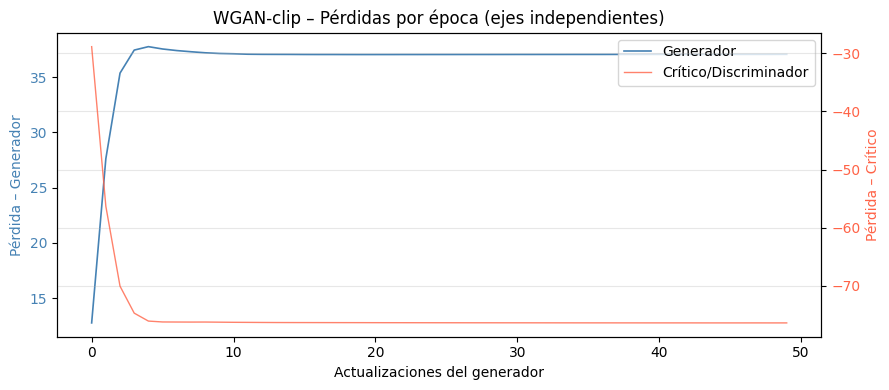


FID – WGAN-clip:


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 344.33

Diversidad – WGAN-clip:
Varianza promedio de píxeles: 0.000754
Distancia promedio inter-img: 8.4541


In [ ]:
print("\n" + "="*60)
print("  Entrenando WGAN-clip con lr=1e-4 y clip_value=0.05")
print("="*60)
wganclip_G_v2, wganclip_C_v2, wc_Gloss_v2, wc_Closs_v2 = train_wgan_clip(
    EPOCHS_WGAN,
    lr=1e-4,
    clip_value=0.05
)

print("\nFID – WGAN-clip:")
fid_wganclip_v2  = compute_fid(wganclip_G_v2)
print("\nDiversidad – WGAN-clip:")
div_wganclip_v2  = analyze_generator_behavior(wganclip_G_v2)

###Guardo modelo

In [ ]:
torch.save(wganclip_G_v2.state_dict(), os.path.join(OUT_WC_v2, "wganclip_G_v2_final.pt"))
print("WGAN-clip_v2 guardado")

##Experimentos de hiperparámetros WGAN-GP
Cada modelo lo guardo dentro de run_experiment, después de train_wgan_gp



Experimentos de hiperparámetros WGAN-GP

  Experimento: C_lam10_nc3
  lambda_gp=10 | n_critic=3 | lr=0.0001
[WGAN-GP_C_lam10_nc3] Epoch 001/50 | LossC: 208.7582 | LossG: 3.0997
[WGAN-GP_C_lam10_nc3] Epoch 005/50 | LossC: -14.8633 | LossG: 0.2570
[WGAN-GP_C_lam10_nc3] Epoch 010/50 | LossC: -11.4900 | LossG: 1.5621
[WGAN-GP_C_lam10_nc3] Epoch 015/50 | LossC: -10.3578 | LossG: 1.4236
[WGAN-GP_C_lam10_nc3] Epoch 020/50 | LossC: -8.8770 | LossG: 2.0608
[WGAN-GP_C_lam10_nc3] Epoch 025/50 | LossC: -8.5462 | LossG: 1.0371
[WGAN-GP_C_lam10_nc3] Epoch 030/50 | LossC: -8.3154 | LossG: 2.1985
[WGAN-GP_C_lam10_nc3] Epoch 035/50 | LossC: -7.7160 | LossG: 3.5894
[WGAN-GP_C_lam10_nc3] Epoch 040/50 | LossC: -7.0874 | LossG: 1.6697
[WGAN-GP_C_lam10_nc3] Epoch 045/50 | LossC: -6.4315 | LossG: 3.9239
[WGAN-GP_C_lam10_nc3] Epoch 050/50 | LossC: -5.9273 | LossG: 3.7855


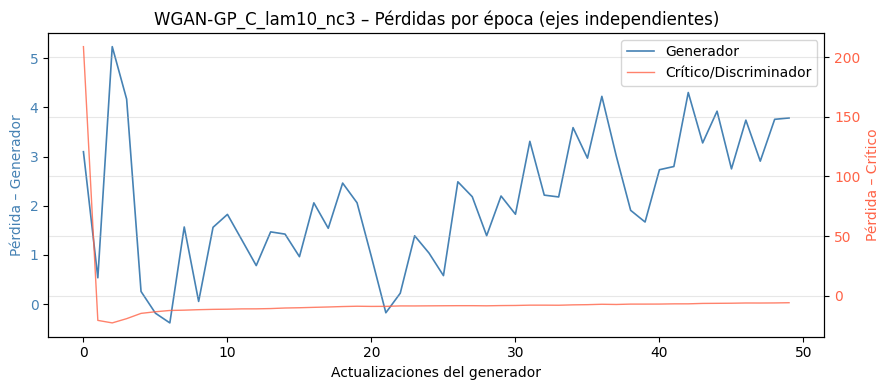

WGAN-GP C_lam10_nc3 guardado
Calculando FID para C_lam10_nc3...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 195MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 85.79
Calculando diversidad para C_lam10_nc3...
Varianza promedio de píxeles: 0.009576
Distancia promedio inter-img: 27.7190

  Experimento: D_lam5_nc5
  lambda_gp=5 | n_critic=5 | lr=0.0001
[WGAN-GP_D_lam5_nc5] Epoch 001/50 | LossC: 50.4400 | LossG: 25.9122
[WGAN-GP_D_lam5_nc5] Epoch 005/50 | LossC: -42.2130 | LossG: 38.0620
[WGAN-GP_D_lam5_nc5] Epoch 010/50 | LossC: -21.2516 | LossG: 40.6562
[WGAN-GP_D_lam5_nc5] Epoch 015/50 | LossC: -18.1320 | LossG: 40.2682
[WGAN-GP_D_lam5_nc5] Epoch 020/50 | LossC: -17.5085 | LossG: 41.2823
[WGAN-GP_D_lam5_nc5] Epoch 025/50 | LossC: -14.8086 | LossG: 46.3470
[WGAN-GP_D_lam5_nc5] Epoch 030/50 | LossC: -13.5519 | LossG: 46.3490
[WGAN-GP_D_lam5_nc5] Epoch 035/50 | LossC: -12.9184 | LossG: 54.2686
[WGAN-GP_D_lam5_nc5] Epoch 040/50 | LossC: -12.4773 | LossG: 52.1113
[WGAN-GP_D_lam5_nc5] Epoch 045/50 | LossC: -12.0202 | LossG: 55.1172
[WGAN-GP_D_lam5_nc5] Epoch 050/50 | LossC: -12.1680 | LossG: 57.4437


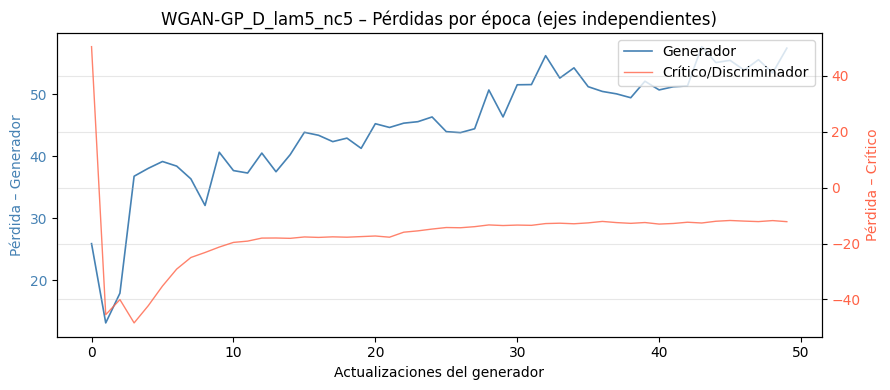

WGAN-GP D_lam5_nc5 guardado
Calculando FID para D_lam5_nc5...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 91.90
Calculando diversidad para D_lam5_nc5...
Varianza promedio de píxeles: 0.013220
Distancia promedio inter-img: 32.4813

  Experimento: E_lam5_nc3
  lambda_gp=5 | n_critic=3 | lr=5e-05
[WGAN-GP_E_lam5_nc3] Epoch 001/50 | LossC: 178.6005 | LossG: 12.6174
[WGAN-GP_E_lam5_nc3] Epoch 005/50 | LossC: -38.7872 | LossG: 21.5273
[WGAN-GP_E_lam5_nc3] Epoch 010/50 | LossC: -18.0731 | LossG: 20.1301
[WGAN-GP_E_lam5_nc3] Epoch 015/50 | LossC: -15.6485 | LossG: 19.4296
[WGAN-GP_E_lam5_nc3] Epoch 020/50 | LossC: -15.8864 | LossG: 22.0454
[WGAN-GP_E_lam5_nc3] Epoch 025/50 | LossC: -14.8266 | LossG: 25.0570
[WGAN-GP_E_lam5_nc3] Epoch 030/50 | LossC: -13.1523 | LossG: 26.8890
[WGAN-GP_E_lam5_nc3] Epoch 035/50 | LossC: -12.8671 | LossG: 28.4110
[WGAN-GP_E_lam5_nc3] Epoch 040/50 | LossC: -12.6141 | LossG: 29.7507
[WGAN-GP_E_lam5_nc3] Epoch 045/50 | LossC: -12.3390 | LossG: 31.1090
[WGAN-GP_E_lam5_nc3] Epoch 050/50 | LossC: -12.1251 | LossG: 32.1501


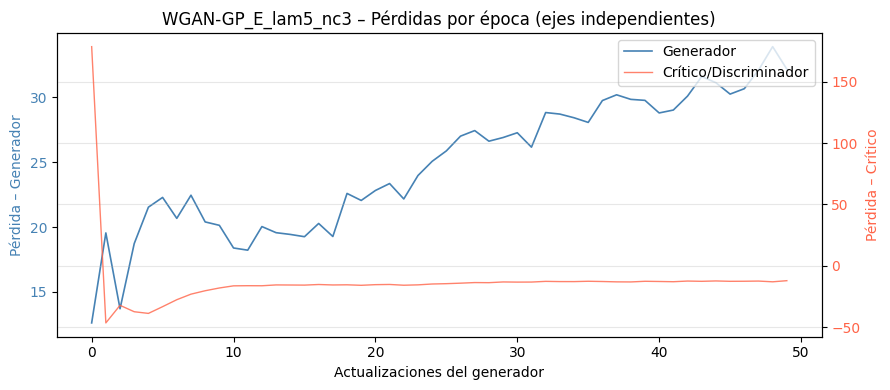

WGAN-GP E_lam5_nc3 guardado
Calculando FID para E_lam5_nc3...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 94.70
Calculando diversidad para E_lam5_nc3...
Varianza promedio de píxeles: 0.012795
Distancia promedio inter-img: 32.0772


In [ ]:
print("\n" + "="*60)
print("Experimentos de hiperparámetros WGAN-GP")
print("="*60)
exp_results = []
for cfg in HP_CONFIGS:
    result = run_experiment(cfg, num_epochs=EPOCHS_WGAN)
    exp_results.append(result)

#Carga de modelos guardados

In [ ]:
#cargar DCGAN
dcgan_G = Generador().to(device)
dcgan_G.load_state_dict(torch.load(os.path.join(OUT_DC, "dcgan_G_final.pt")))
dcgan_G.eval()
print("DCGAN cargado")

# cargar WGAN-clip
wganclip_G = Generador().to(device)
wganclip_G.load_state_dict(torch.load(os.path.join(OUT_WC, "wganclip_G_final.pt")))
wganclip_G.eval()
print("WGAN-clip cargado")

# # cargar WGAN-clip_v2
# wganclip_G_v2 = Generador().to(device)
# wganclip_G_v2.load_state_dict(torch.load(os.path.join(OUT_WC_v2, "wganclip_G_v2_final.pt")))
# wganclip_G_v2.eval()
# print("wganclip_G_v2 cargado")

# cargar WGAN-GP por config
exp_results = []
for cfg in HP_CONFIGS:
    out_dir = os.path.join(OUT_EXP, cfg["name"])
    netG = Generador().to(device)
    netG.load_state_dict(torch.load(os.path.join(out_dir, f"wgangp_G_{cfg['name']}_final.pt")))
    netG.eval()
    exp_results.append({
        "config"             : cfg["name"],
        "lambda_gp"          : cfg["lambda_gp"],
        "n_critic"           : cfg["n_critic"],
        "lr"                 : cfg["lr"],
        "model"              : netG,
        "FID"                : None,
        "pixel_variance"     : None,
        "mean_pairwise_distance": None,
    })
    print(f"WGAN-GP {cfg['name']} cargado")



DCGAN cargado
WGAN-clip cargado
WGAN-GP B_lam10_nc5 cargado
WGAN-GP C_lam10_nc3 cargado
WGAN-GP D_lam5_nc5 cargado
WGAN-GP E_lam5_nc3 cargado


In [ ]:
exp_results = []
for cfg in HP_CONFIGS:
    out_dir = os.path.join(OUT_EXP, cfg["name"])
    netG = Generador().to(device)
    netG.load_state_dict(torch.load(os.path.join(out_dir, f"wgangp_G_{cfg['name']}_final.pt")))
    netG.eval()
    print(f"WGAN-GP {cfg['name']} cargado")

    print(f"Calculando FID para {cfg['name']}...")
    fid = compute_fid(netG)

    print(f"Calculando diversidad para {cfg['name']}...")
    div = analyze_generator_behavior(netG)

    exp_results.append({
        "config"                 : cfg["name"],
        "lambda_gp"              : cfg["lambda_gp"],
        "n_critic"               : cfg["n_critic"],
        "lr"                     : cfg["lr"],
        "model"                  : netG,
        "FID"                    : fid,
        "pixel_variance"         : div["pixel_variance"],
        "mean_pairwise_distance" : div["mean_pairwise_distance"],
    })

WGAN-GP B_lam10_nc5 cargado
Calculando FID para B_lam10_nc5...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 90.46
Calculando diversidad para B_lam10_nc5...
Varianza promedio de píxeles: 0.010664
Distancia promedio inter-img: 28.8184
WGAN-GP C_lam10_nc3 cargado
Calculando FID para C_lam10_nc3...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 87.06
Calculando diversidad para C_lam10_nc3...
Varianza promedio de píxeles: 0.009515
Distancia promedio inter-img: 27.6551
WGAN-GP D_lam5_nc5 cargado
Calculando FID para D_lam5_nc5...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 90.71
Calculando diversidad para D_lam5_nc5...
Varianza promedio de píxeles: 0.012721
Distancia promedio inter-img: 31.9236
WGAN-GP E_lam5_nc3 cargado
Calculando FID para E_lam5_nc3...


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 94.08
Calculando diversidad para E_lam5_nc3...
Varianza promedio de píxeles: 0.012156
Distancia promedio inter-img: 31.3058


#Tabla comparativa

In [ ]:
print("\nFID – DCGAN:")
fid_dcgan  = compute_fid(dcgan_G)
print("\nDiversidad – DCGAN:")
div_dcgan  = analyze_generator_behavior(dcgan_G)
print("\nFID – WGAN-clip:")
fid_wganclip = compute_fid(wganclip_G)
print("\nDiversidad – WGAN-clip:")
div_wganclip = analyze_generator_behavior(wganclip_G)


FID – DCGAN:


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 47.40

Diversidad – DCGAN:
Varianza promedio de píxeles: 0.013054
Distancia promedio inter-img: 31.5401

FID – WGAN-clip:


/usr/local/lib/python3.12/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


  FID = 353.62

Diversidad – WGAN-clip:
Varianza promedio de píxeles: 0.009537
Distancia promedio inter-img: 30.0479


In [ ]:
print_results_table(fid_dcgan, fid_wganclip, exp_results, div_dcgan, div_wganclip)


Modelo                            FID     Var. pix   Dist. media
--------------------------------------------------------------------------------
DCGAN (baseline)                47.40     0.013054       31.5401
WGAN-clip                      353.62     0.009537       30.0479
WGAN-GP (B_lam10_nc5)           90.46     0.010664       28.8184
WGAN-GP (C_lam10_nc3)           87.06     0.009515       27.6551
WGAN-GP (D_lam5_nc5)            90.71     0.012721       31.9236
WGAN-GP (E_lam5_nc3)            94.08     0.012156       31.3058


#Comparación cualitativa


WGAN-clip v1 (lr=5e-5, clip=0.01)


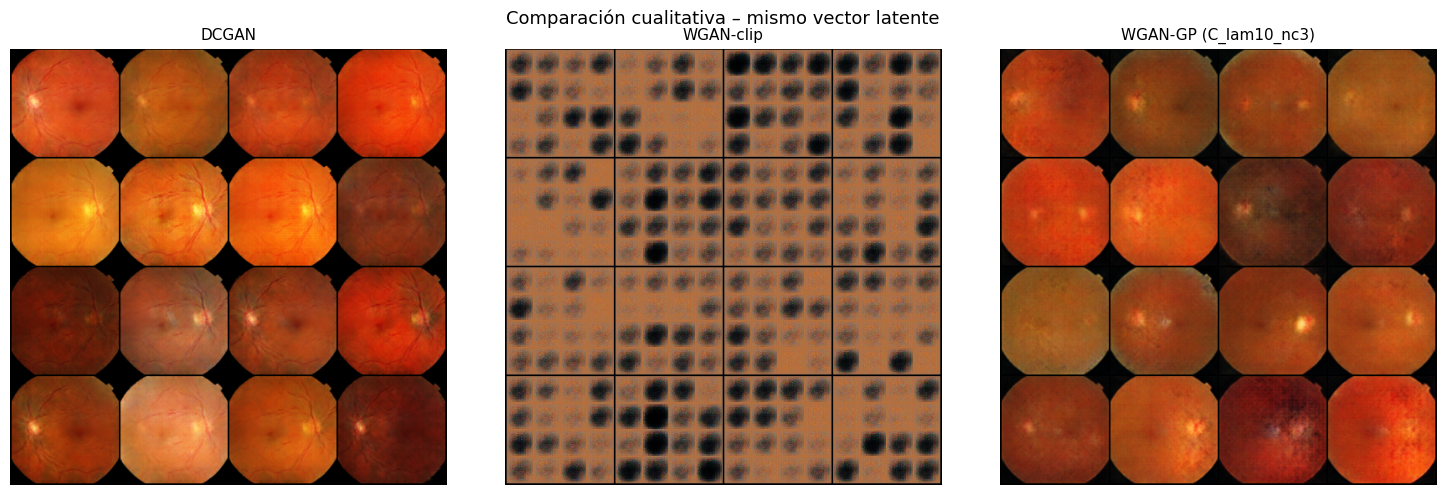

In [ ]:
print("WGAN-clip v1 (lr=5e-5, clip=0.01)")
plot_comparison_all(dcgan_G, wganclip_G, exp_results)

# print("WGAN-clip v2 (lr=1e-4, clip=0.05)")
# plot_comparison_all(dcgan_G, wganclip_G_v2, exp_results)

#Genero dataset sintético con la mejor config WGAN-GP

In [ ]:
best_result = min(exp_results, key=lambda r: r["FID"])
print(f"\nMejor configuración WGAN-GP: {best_result['config']} (FID={best_result['FID']:.2f})")

SYN_DIR = os.path.join(OUT_BASE, f"synthetic_wgangp_{best_result['config']}")

def generate_dataset_png(netG, n_images=2000, out_dir=SYN_DIR, batch_size=64):
    os.makedirs(out_dir, exist_ok=True)
    netG.eval()
    saved = 0
    with torch.no_grad():
        while saved < n_images:
            cur  = min(batch_size, n_images - saved)
            z    = torch.randn(cur, NZ, 1, 1, device=device)
            fake = denorm(netG(z).detach().cpu())
            for i in range(cur):
                save_image(fake[i], os.path.join(out_dir, f"fake_{saved+i:05d}.png"))
            saved += cur
    netG.train()
    print(f"Dataset sintético guardado: {n_images} imágenes en {out_dir}")

generate_dataset_png(best_result["model"], n_images=2000)


Mejor configuración WGAN-GP: C_lam10_nc3 (FID=87.06)
Dataset sintético guardado: 2000 imágenes en /content/drive/My Drive/2026/Ciencias Cognitivas/Proyecto final/gan_outputs_2/synthetic_wgangp_C_lam10_nc3


#Arquitecturas

In [ ]:
print("\nGenerador:")
print(Generador())
print("\nDiscriminador DCGAN:")
print(D_DCGAN())
print("\nCrítico WGAN (InstanceNorm):")
print(Critic_WGAN())


Generador:
Generador(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): B